# A LangGraph-Orchestrated Framework for Secure Analysis and Repair of LLM-Generated Code

## Experimental Evaluation Notebook

**Authors**

Lizeth Campos Velazquez  
Bikash Chandra Singh  

California State University, Fresno

---

This notebook accompanies the paper and provides a reviewer-facing interface for inspecting the frozen workflow configuration, benchmark
materials, experiment scripts, prompts, archived outputs, and reported
evaluation results.

All displayed numerical results are loaded from the
archived evaluation artifacts used to prepare the paper.

> **Reviewer path:** Select **Runtime → Run all**.
>
> The notebook loads the public evaluation repository and presents its
> archived artifacts. It does not call Anthropic, OpenAI, LangSmith, or
> any other external model service.

## Notebook Contents

1. [Overview](#overview)
2. [Reviewer Checklist](#reviewer-checklist)
3. [Repository Organization](#repository-organization)
4. [Evaluated Workflow](#experimental-workflow)
5. [Environment Setup](#environment-setup)
6. [Frozen Configuration](#final-configuration-summary)
7. [Benchmark Inspection](#benchmark-inspection)
8. [Prompts and Experiment Scripts](#prompts-and-scripts)
9. [Reported Calibration Results](#workflow-calibration)
10. [Reported Detection Results](#experiment-1-detection-and-comparative-analysis)
11. [Reported Remediation Results](#experiment-2-end-to-end-secure-remediation)
12. [Reported Chained-Vulnerability Results](#experiment-3-chained-vulnerability-evaluation)
13. [Reported Runtime and Cost](#runtime-and-cost-analysis)
14. [Paper Table Inventory](#paper-table-inventory)
15. [Supporting Logs and Outputs](#supporting-artifacts)
16. [Artifact Summary](#artifact-summary)
17. [References](#references)

<a name="overview"></a>

# 1. Overview

This notebook provides structured access to the public evaluation
repository accompanying the paper.

Its purpose is to help reviewers inspect:

- the frozen workflow configuration;
- benchmark samples and metadata;
- prompts used during evaluation;
- experiment scripts;
- archived experiment logs and outputs;
- Tables I–VIII reported in the paper;
- the architecture figure;
- runtime and cost provenance.



### Scope of This Artifact

The repository contains:

- the 138-case SecurityEval-derived benchmark;
- the 18-case calibration subset;
- chained-vulnerability scenario materials;
- frozen workflow documentation;
- evaluation prompts;
- experiment scripts;
- experiment logs;
- representative model and tool outputs;
- reported-result CSV files;
- the architecture figure;
- runtime and cost documentation.

The experiment scripts document how the evaluation was conducted.
They are included for methodological transparency but are not executed
by this notebook.

<a name="reviewer-checklist"></a>

# 2. Reviewer Checklist

This notebook allows reviewers to:

- [ ] Confirm that the public repository loads successfully
- [ ] Inspect the frozen workflow configuration
- [ ] Inspect the benchmark organization
- [ ] Locate prompts and experiment scripts
- [ ] View reported Tables I–VIII
- [ ] Inspect the architecture figure
- [ ] Locate experiment logs and representative outputs
- [ ] Review runtime and cost provenance
- [ ] Confirm that all paper-supporting artifacts are available

<a name="repository-organization"></a>
# 3. Repository Organization

The evaluation repository is organized as follows:

```text
repository-root/
│
├── configs/
│   ├── README.md
│   └── workflow_configuration.md
│
├── datasets/
│   ├── chains/
│   ├── securityeval/
│   └── README.md
│
├── experiments/
│   ├── README.md
│   ├── experiment1/
│   ├── experiment2/
│   ├── experiment3/
│   ├── calibration/
│   └── methodology.md
│
├── notebooks/
│   ├── README.md
│   └── paper_reproduction.ipynb
│
├── prompts/
│   ├── chain_reasoning_prompt.md
│   ├── chain_repair_prompt.md
│   ├── detector_prompt.md
│   ├── repair_prompt.md
│   ├── secure_counterpart_generation_prompt.md
│   └── README.md
│
├── results/
│   ├── paper_results/
│   └── README.md

│
├── CITATION.cff
├── requirements.txt
└── README.md

### Directory Roles

| Directory | Purpose |
|---|---|
| `configs/` | Documents the calibrated and frozen experimental configuration. |
| `datasets/` | Contains or documents the benchmark data used in the evaluation. |
| `experiments/` | Contains experiment scripts, methodology, and evaluation utilities. |
| `notebooks/` | Provides the reviewer-facing inspection notebook. |
| `prompts/` | Stores the prompt templates used during benchmark preparation and experimentation. |
| `results/paper_results/` | Stores the archived outputs used to produce the paper's reported results. |

<a name="experimental-workflow"></a>
# 4. Experimental Workflow

The evaluated workflow uses graph-based orchestration to coordinate security analysis, retrieval, vulnerability detection, conditional repair, and structured reporting.

At a high level, the standard workflow follows this sequence:

```text
Input
  ↓
Preprocessing
  ↓
Hybrid Security Retrieval
  ↓
Vulnerability Detection
  ↓
Conditional Repair
  ↓
Structured Security Report

```

The chained-vulnerability evaluation extends this process with multi-component analysis, validated individual findings, chain reasoning, and coordinated repair planning.



### Workflow Figure

The workflow architecture is shown below.

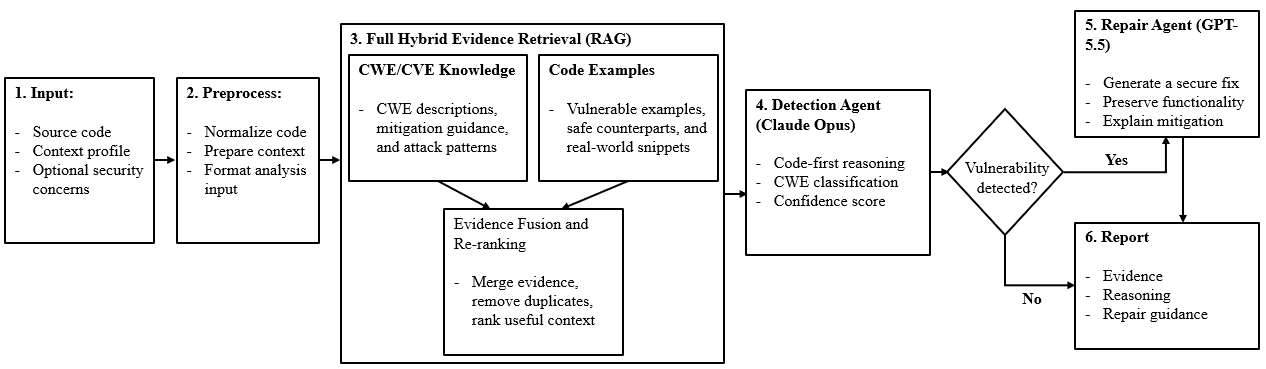

Source: results/paper_results/figures/Overall-architecture.png


In [31]:
architecture_path = (
    PAPER_RESULTS
    / "figures"
    / "Overall-architecture.png"
)

if not architecture_path.exists():
    raise FileNotFoundError(
        f"Architecture figure not found: {architecture_path}"
    )

display(
    Image(
        filename=str(architecture_path),
        width=1100
    )
)

print(f"Source: {architecture_path.relative_to(REPO_DIR)}")

<a name="environment-setup"></a>
# 5. Environment Setup

This section prepares a clean Google Colab environment for the reproduction workflow.

It performs the following tasks:

1. clone the evaluation repository;
2. install the required Python dependencies;
3. establish repository-relative paths;
4. verify the required directories and files;
5. display the active runtime environment;
6. initialize Analysis Mode without requiring API credentials.


In [2]:
# ============================================================
# Repository Setup
# ============================================================

from pathlib import Path
import os
import sys

# Detect Google Colab
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Google Colab: {IN_COLAB}")

# Repository information
REPO_NAME = "llm-security-framework-evaluation"
REPO_URL = "https://github.com/lizethcampos03/llm-security-framework-evaluation.git"

if IN_COLAB:
    REPO_DIR = Path("/content") / REPO_NAME
else:
    REPO_DIR = Path.cwd()

print(f"Repository directory: {REPO_DIR}")

Running in Google Colab: True
Repository directory: /content/llm-security-framework-evaluation


## Clone Repository

In [3]:
if IN_COLAB:

    if not REPO_DIR.exists():

        !git clone {REPO_URL}

    else:

        print("Repository already exists.")

os.chdir(REPO_DIR)

print(f"Current working directory:\n{Path.cwd()}")

Cloning into 'llm-security-framework-evaluation'...
remote: Enumerating objects: 581, done.
remote: Counting objects: 100% (581/581), done.
remote: Compressing objects: 100% (305/305), done.
remote: Total 581 (delta 281), reused 564 (delta 272), pack-reused 0 (from 0)
Receiving objects: 100% (581/581), 1.57 MiB | 20.61 MiB/s, done.
Resolving deltas: 100% (281/281), done.
Current working directory:
/content/llm-security-framework-evaluation


## Install Dependencies

In [4]:
!pip install -q pandas numpy matplotlib

## Import Packages

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("Imports completed successfully.")

Imports completed successfully.


## Repository Paths

In [6]:
CONFIG_DIR = REPO_DIR / "configs"

RESULTS_DIR = REPO_DIR / "results"

PAPER_RESULTS = RESULTS_DIR / "paper_results"

TABLES_DIR = PAPER_RESULTS / "tables"

FIGURES_DIR = PAPER_RESULTS / "figures"

OUTPUT_DIR = RESULTS_DIR / "reproduced_results"

print(TABLES_DIR)

/content/llm-security-framework-evaluation/results/paper_results/tables


## Repository Validation

In [7]:
required_files = {

    "Workflow Configuration":
        CONFIG_DIR / "workflow_configuration.md",

    "Calibration Results":
        TABLES_DIR / "calibration_results.csv",

    "Experiment 1 Results":
        TABLES_DIR / "experiment1_detection_results.csv",

    "Confusion Matrix":
        TABLES_DIR / "experiment1_confusion_matrix.csv",

    "Comparative Results":
        TABLES_DIR / "comparative_detection_results.csv",

    "End-to-End Results":
        TABLES_DIR / "end_to_end_workflow_results.csv",

    "Chain Scenarios":
        TABLES_DIR / "chained_vulnerability_scenarios.csv",

    "Chain Results":
        TABLES_DIR / "chained_vulnerability_results.csv",

    "Runtime Cost Summary":
        TABLES_DIR / "runtime_cost_summary.csv",
}

validation = []

for name, path in required_files.items():

    validation.append({
        "Artifact": name,
        "Exists": path.exists()
    })

validation_df = pd.DataFrame(validation)

display(validation_df)

,Artifact,Exists
0,Workflow Configuration,True
1,Calibration Results,True
2,Experiment 1 Results,True
3,Confusion Matrix,True
4,Comparative Results,True
5,End-to-End Results,True
6,Chain Scenarios,True
7,Chain Results,True
8,Runtime Cost Summary,True


## Artifact Display Utilities

The following helper functions load and display archived repository
artifacts without altering their contents.

In [8]:
from IPython.display import Markdown, Image, display
import json


def load_reported_table(filename, required_columns=None):
    """Load an archived reported-result CSV."""
    path = TABLES_DIR / filename

    if not path.exists():
        raise FileNotFoundError(f"Table not found: {path}")

    dataframe = pd.read_csv(path)

    if required_columns:
        missing = [
            column
            for column in required_columns
            if column not in dataframe.columns
        ]

        if missing:
            raise ValueError(
                f"{filename} is missing columns: {missing}"
            )

    return dataframe


def display_markdown_file(path, title=None):
    """Display a Markdown artifact in the notebook."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Markdown file not found: {path}")

    if title:
        display(Markdown(f"### {title}"))

    display(Markdown(path.read_text(encoding="utf-8")))


def preview_json_file(path, max_characters=4000):
    """Display a concise preview of an archived JSON output."""
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"JSON file not found: {path}")

    with path.open("r", encoding="utf-8") as file:
        data = json.load(file)

    rendered = json.dumps(data, indent=2)

    if len(rendered) > max_characters:
        rendered = (
            rendered[:max_characters]
            + "\n\n... preview truncated ..."
        )

    print(rendered)


print("Artifact display utilities are ready.")

Artifact display utilities are ready.


<a name="final-configuration-summary"></a>

# 6. Frozen Configuration

The following section presents the archived configuration of the workflow
used for the reported evaluation. The configuration was selected during
calibration and frozen before the primary benchmark experiments.

### Configuration Summary

The complete archived configuration is stored in
`configs/workflow_configuration.md`. A concise reviewer-facing summary is
displayed below.

In [9]:
configuration_summary = pd.DataFrame(
    [
        ["Orchestration framework", "LangGraph"],
        ["Detection model", "Claude Opus"],
        ["Repair model", "GPT-5.5"],
        ["Retrieval strategy", "Full Hybrid Evidence Retrieval"],
        ["Detection approach", "Code-first, context-aware analysis"],
        ["Repair routing", "Conditional"],
        ["Primary benchmark", "138 cases: 69 vulnerable and 69 safe"],
    ],
    columns=["Component", "Archived Configuration"],
)

display(configuration_summary)

,Component,Archived Configuration
0,Orchestration framework,LangGraph
1,Detection model,Claude Opus
2,Repair model,GPT-5.5
3,Retrieval strategy,Full Hybrid Evidence Retrieval
4,Detection approach,"Code-first, context-aware analysis"
5,Repair routing,Conditional
6,Primary benchmark,138 cases: 69 vulnerable and 69 safe


### Archived Workflow Configuration

In [10]:
configuration_path = CONFIG_DIR / "workflow_configuration.md"

display_markdown_file(configuration_path)

# Workflow Configuration

## Purpose

This document describes the final workflow configuration evaluated in the
accompanying paper.

The primary LangGraph Security Framework was established after calibration
and remained frozen during the detection, comparative, and remediation
evaluations. A separate optional chained-vulnerability branch was added for
the preliminary multi-component attack-path evaluation.

This document provides a concise technical specification of both:

1. the frozen primary workflow; and
2. the experimental chained-vulnerability analysis extension.

It does not require readers to inspect the private implementation code.

---

# 1. Frozen Primary Workflow

The finalized primary LangGraph Security Framework consists of the following
stages:

```text
Input
    ↓
Preprocessing
    ↓
Full Hybrid Evidence Retrieval
    ↓
Claude Opus Vulnerability Detection
    ↓
Vulnerability Detected?
      ├── No → Structured Security Report
      └── Yes
              ↓
      Conditional Secure Repair
              ↓
      Structured Security Report
```

The primary workflow was used for:

- workflow calibration;
- the 138-case detection benchmark;
- comparison with GPT-4, CodeQL, and Bandit; and
- end-to-end remediation analysis.

The chained-vulnerability evaluation did not replace this architecture.
Instead, it extended the workflow through an optional reasoning branch for
multi-component inputs.

---

# 2. Primary Workflow Components

| Stage | Purpose |
|---|---|
| Input | Receives source code, a context profile, and optional user-supplied security concerns. |
| Preprocessing | Normalizes the source code, prepares contextual information, and formats the analysis input. |
| Full Hybrid Evidence Retrieval | Retrieves relevant CWE knowledge, vulnerable examples, safe counterparts, and mitigation evidence through hybrid keyword and vector retrieval. |
| Claude Opus Detection | Determines whether the code contains a security weakness using code-first reasoning supported by retrieved evidence. |
| Conditional Repair | Generates a secure implementation only when a vulnerability is detected and the workflow is operating in repair mode. |
| Structured Report | Produces a machine-readable security report containing findings, evidence, reasoning, CWE mappings, confidence information, and remediation guidance. |

---

# 3. Model Configuration

The workflow uses specialized language models for different tasks.

| Component | Configured Model |
|---|---|
| Vulnerability Detection | Claude Opus |
| Primary Secure-Repair Configuration | GPT-5.5 |
| Chained-Vulnerability Reasoning | Claude Opus |
| Chain Repair Planning | GPT-5.5 |

Claude Opus was selected for vulnerability detection and reasoning because the task
requires reasoning about code behavior, attack surfaces, application
context, and security implications.

GPT-5.5 was selected as the configured repair model because the repair task
requires code synthesis, instruction following, and
functionality-preserving modification.

Default provider API parameters were used without manual tuning of
temperature, top-p, or other generation settings.

## Comparative Remediation Control

The comparative end-to-end remediation experiment used GPT-4-0613 as the
repair model for both the published GPT-4 baseline and the proposed
workflow.

This controlled comparison isolated the effect of the structured LangGraph
security report. Therefore, the reported improvement in remediation could
not be attributed to using a stronger repair model.

The GPT-4-0613 experiment-specific control should not be confused with the
framework's configured GPT-5.5 repair stage.

---

# 4. Retrieval Configuration

The primary workflow uses the **Full Hybrid Evidence Reranker** configuration.

The retrieval pipeline combines multiple complementary sources of evidence.

## Retrieval Channels

- code keyword retrieval;
- code vector retrieval;
- CWE keyword retrieval;
- CWE vector retrieval.

Retrieved evidence is subsequently:

- merged;
- deduplicated;
- weighted;
- reranked.

The resulting evidence package is supplied to the vulnerability detector.

This configuration was selected during calibration because it produced
stronger contextual evidence than keyword-only or vector-only retrieval.

---

# 5. Prompt Design Philosophy

The workflow emphasizes evidence quality and disciplined reasoning rather
than prompt length alone.

## Code-First Reasoning

Source code is treated as the primary source of truth.

Retrieved evidence supports the analysis but is not considered proof of a
vulnerability by itself.

## Context-Aware Analysis

Context profiles describe intended behavior, deployment assumptions, trust
boundaries, authentication expectations, and other information that may
affect whether observed code behavior is security relevant.

## Safe-Counterpart Reasoning

When applicable, the detector compares potentially vulnerable behavior with
retrieved secure examples before issuing its final classification.

## Evidence-Guided Decisions

A vulnerability should be reported only when the observed implementation
and the retrieved security evidence jointly support the finding.

## Structured Output

The detector produces structured outputs containing:

- vulnerability classification;
- associated CWE information;
- code evidence;
- retrieved evidence;
- confidence;
- reasoning;
- remediation guidance.

---

# 6. Workflow Optimizations

Calibration produced several architectural decisions that became part of
the frozen primary workflow.

| Optimization | Final Decision |
|---|---|
| Retrieval Strategy | Full Hybrid Evidence Reranker |
| Detector Model | Claude Opus |
| Validation Node | Removed |
| Repair Generation | Conditional |
| Output Format | Structured security report |

The dedicated validation node was removed because repeated detector
execution substantially increased latency without producing measurable
improvement in detection quality.

Repair generation became conditional so that safe samples did not incur
unnecessary repair-model calls, reducing latency and API cost.

---

# 7. Chained-Vulnerability Analysis Extension

## Purpose

The chained-vulnerability extension provides a preliminary mechanism for
reasoning about relationships among vulnerabilities detected across multiple
software components.

Its purpose is to move beyond isolated weakness classification toward:

- candidate attack-chain construction;
- evidence-supported attack-path reasoning;
- chain validation and prioritization;
- chain-aware remediation planning; and
- structured chain reporting.

The extension is experimental and was used only for the preliminary
chained-vulnerability evaluation.

## Relationship to the Primary Workflow

The extension begins after the primary framework has analyzed individual
components.

The primary workflow remains responsible for:

- component preprocessing;
- evidence retrieval;
- vulnerability detection;
- CWE-oriented findings; and
- structured component reports.

When a multi-component input contains sufficient validated findings, the
optional chain-analysis branch receives those findings together with
architectural context.

```text
Frozen Primary Workflow
        ↓
Confirmed Component Vulnerabilities
        ↓
Candidate Chain Construction
        ↓
CWE/CAPEC-Guided Attack-Path Reasoning
        ↓
Chain Validation and Prioritization
        ↓
Chain-Aware Repair Planning
        ↓
Extended Chain Report
```

## Multi-Component Inputs

The extension operates on scenarios containing multiple related component
files and supporting context describing:

- component relationships;
- data flows;
- shared resources;
- trust boundaries;
- attacker capabilities;
- deployment assumptions.

Expected CWE assignments are withheld during execution and are used only
afterward for evaluation.

## Stage 1: Confirmed Component Vulnerabilities

The branch receives independently detected component-level findings from
the primary workflow.

Each finding may include:

- affected component;
- detected vulnerability;
- code evidence;
- component context;
- CWE information;
- confidence and reasoning.

**Output:** confirmed component vulnerability findings.

## Stage 2: Candidate Chain Construction

The system searches for plausible relationships among independently
detected vulnerabilities.

Candidate relationships are informed by:

- cross-component data flow;
- trust-boundary crossings;
- shared credentials or resources;
- attacker-controlled inputs;
- preconditions and postconditions;
- escalation opportunities.

**Output:** candidate vulnerability chains.

## Stage 3: Attack-Path Reasoning

An LLM-based reasoning stage evaluates each proposed chain using component
context and retrieved CWE/CAPEC evidence.

The reasoning process considers:

- whether one vulnerability enables or strengthens another;
- required attacker capabilities;
- exploit preconditions;
- intermediate state transitions;
- likely impact;
- whether the proposed progression is supported by available evidence.

**Output:** feasibility analysis and attack-path reasoning evidence.

## Stage 4: Chain Validation and Prioritization

Candidate chains are validated according to the strength of the supporting
evidence.

Unsupported relationships are not accepted as confirmed attack paths.

Supported chains may be prioritized according to:

- likelihood;
- exploit feasibility;
- potential impact;
- criticality of affected resources;
- importance of the involved control points.

**Output:** validated and prioritized chains.

## Stage 5: Chain-Aware Repair Planning

For evidence-supported chains, the extension generates a remediation plan
designed to break the attack path.

The plan identifies:

- vulnerabilities requiring remediation;
- critical control points;
- cross-component mitigations;
- recommended validation steps;
- dependencies among repairs.

The experimental extension produces repair plans rather than automatically
applying coordinated multi-file patches.

**Output:** chain-aware remediation plan.

## Stage 6: Extended Chain Report

The final output extends the standard security report with:

- component findings;
- candidate chains;
- validated attack paths;
- CWE/CAPEC supporting evidence;
- feasibility reasoning;
- preconditions and progression;
- expected impact;
- prioritization;
- chain-aware remediation guidance.

**Output:** structured chain-aware report and summary.

---

# 8. Chained-Vulnerability Evaluation Scope

The preliminary evaluation included four representative multi-component
scenarios.

The framework reported:

- component-level vulnerability detection in four of four scenarios;
- candidate-chain identification in four of four scenarios;
- confirmed attack paths in three of four scenarios; and
- repair plans in three of four scenarios.

The Code Injection–Sensitive Operation scenario remained unconfirmed because
the available evidence did not support a complete attack path.

The extension should not be interpreted as:

- a complete attack-graph construction system;
- a generalizable attack-chain accuracy benchmark;
- dynamic exploit validation;
- proof that every candidate relationship is exploitable;
- an automated multi-file patching system.

Chain confirmation represents evidence-supported reasoning under controlled
experimental conditions and was manually reviewed.

---

# 9. Architecture Figures

The repository contains separate figures for the two architectural views:

- the frozen primary workflow used for the main benchmark; and
- the optional chained-vulnerability analysis extension used for the
  preliminary attack-path experiment.

The extension figure illustrates the progression from confirmed component
vulnerabilities through chain construction, LLM-based attack-path reasoning,
chain validation, repair planning, and extended reporting.

---

# 10. Final Evaluated Configuration

## Primary Workflow

| Component | Configuration |
|---|---|
| Workflow | LangGraph Security Framework |
| Retrieval | Full Hybrid Evidence Reranker |
| Detection Model | Claude Opus |
| Configured Repair Model | GPT-5.5 |
| Prompt Philosophy | Code-first, context-aware, evidence-guided reasoning |
| Validation Node | Removed |
| Repair Strategy | Conditional repair generation |
| Primary Output | Structured security report |

## Optional Experimental Extension

| Component | Configuration |
|---|---|
| Input Type | Multi-component scenarios |
| Starting Evidence | Confirmed component vulnerability findings |
| Chain Construction | Component relationships, data flow, trust boundaries, and attacker capabilities |
| Security Knowledge | CWE and CAPEC evidence |
| Reasoning | LLM-based attack-path feasibility analysis |
| Validation | Evidence-supported chain confirmation and prioritization |
| Remediation | Chain-aware repair planning |
| Extension Output | Structured chain report and remediation plan |
| Automatic Multi-File Patching | Not performed |

No architectural modifications were introduced into the frozen primary
workflow after calibration.

The chain-analysis capability was evaluated as a separate optional branch and
did not alter the configuration used to report the primary benchmark
detection results.

---

# 11. Relationship to the Repository

This document specifies **what** workflow configuration was evaluated.

Additional repository artifacts provide complementary information:

- `prompts/` contains the archived prompt templates;
- `datasets/` contains benchmark samples, context profiles, and chain
  scenarios;
- `experiments/` contains experiment-specific execution scripts;
- `results/paper_results/experiment_logs/` contains experiment logs;
- `results/paper_results/outputs/` contains representative archived outputs;
- `results/paper_results/tables/` contains the values reported in the paper;
- `results/paper_results/figures/` contains the architecture figures.

Together, these resources document the evaluated workflow, experimental
extension, procedures, and reported results while keeping configuration,
experimentation, and outputs logically separated.

<a name="benchmark-inspection"></a>

# 7. Benchmark Inspection

The primary benchmark contains one vulnerable sample and one verified
safe counterpart for each of 69 CWE families, producing 138 total cases.

This section inspects the organization of the archived benchmark. It does
not execute the samples or recalculate experimental performance.

In [11]:
SECURITYEVAL_DIR = (
    REPO_DIR
    / "datasets"
    / "securityeval"
    / "securityeval_dataset"
)

cwe_directories = sorted(
    [
        path
        for path in SECURITYEVAL_DIR.iterdir()
        if path.is_dir() and path.name.startswith("CWE-")
    ]
)

benchmark_summary = pd.DataFrame(
    [
        ["CWE families", len(cwe_directories)],
        ["Vulnerable samples", len(cwe_directories)],
        ["Safe counterparts", len(cwe_directories)],
        ["Total benchmark cases", len(cwe_directories) * 2],
    ],
    columns=["Artifact", "Count"],
)

display(benchmark_summary)

,Artifact,Count
0,CWE families,69
1,Vulnerable samples,69
2,Safe counterparts,69
3,Total benchmark cases,138


In [12]:
representative_cwes = cwe_directories[:5]

sample_inventory = []

for cwe_dir in representative_cwes:
    sample_inventory.append(
        {
            "CWE": cwe_dir.name,
            "Vulnerable Sample": (
                cwe_dir / "vulnerable_securityeval_sample.py"
            ).exists(),
            "Safe Counterpart": (
                cwe_dir / "safe_verified_counterpart.py"
            ).exists(),
            "Context Profile": (
                cwe_dir / "context_profile.json"
            ).exists(),
            "Assignment Metadata": (
                cwe_dir / "assignment.json"
            ).exists(),
        }
    )

display(pd.DataFrame(sample_inventory))

,CWE,Vulnerable Sample,Safe Counterpart,Context Profile,Assignment Metadata
0,CWE-113,True,True,True,True
1,CWE-116,True,True,True,True
2,CWE-117,True,True,True,True
3,CWE-1204,True,True,True,True
4,CWE-193,True,True,True,True


### Representative Benchmark Pair

The following code samples are shown only to illustrate the structure of
the archived benchmark.

In [13]:
example_directory = cwe_directories[0]

vulnerable_path = (
    example_directory / "vulnerable_securityeval_sample.py"
)
safe_path = (
    example_directory / "safe_verified_counterpart.py"
)

print(f"Example CWE: {example_directory.name}")

print("\n--- Vulnerable sample ---\n")
print(vulnerable_path.read_text(encoding="utf-8"))

print("\n--- Verified safe counterpart ---\n")
print(safe_path.read_text(encoding="utf-8"))

Example CWE: CWE-113

--- Vulnerable sample ---

from flask import Response, request, Flask
from werkzeug.datastructures import Headers

app = Flask(__name__)


@app.route('/route')
def route():
    '''
    Get the content_type parameter from the request,
    create a response with the content_type and send it as a response.
    '''
    content_type = request.args["Content-Type"]
    response = Response()
    headers = Headers()
    headers.add("Content-Type", content_type)
    response.headers = headers
    return response


--- Verified safe counterpart ---

from flask import Response, request, Flask
from werkzeug.datastructures import Headers
import re

app = Flask(__name__)


@app.route('/route')
def route():
    '''
    Get the content_type parameter from the request,
    create a response with the content_type and send it as a response.
    '''
    content_type = request.args.get("Content-Type", "")

    # Remove CRLF characters to prevent HTTP header injection
    content_type =

<a name="prompts-and-scripts"></a>

# 8. Prompts and Experiment Scripts

The public repository includes the prompts and experiment scripts used
during the evaluation.

The scripts document the experimental procedures but are not executed by
this notebook.

In [14]:
PROMPTS_DIR = REPO_DIR / "prompts"

prompt_files = sorted(PROMPTS_DIR.glob("*.md"))

prompt_inventory = pd.DataFrame(
    [
        {
            "Prompt File": path.name,
            "Repository Path": str(path.relative_to(REPO_DIR)),
        }
        for path in prompt_files
        if path.name.lower() != "readme.md"
    ]
)

display(prompt_inventory)

,Prompt File,Repository Path
0,chain_reasoning_prompt.md,prompts/chain_reasoning_prompt.md
1,chain_repair_prompt.md,prompts/chain_repair_prompt.md
2,detector_prompt.md,prompts/detector_prompt.md
3,repair_prompt.md,prompts/repair_prompt.md
4,secure_counterpart_generation_prompt.md,prompts/secure_counterpart_generation_prompt.md


In [15]:
EXPERIMENTS_DIR = REPO_DIR / "experiments"

experiment_scripts = sorted(
    EXPERIMENTS_DIR.rglob("*.py")
)

script_inventory = pd.DataFrame(
    [
        {
            "Script": path.name,
            "Experiment Area": path.parent.name,
            "Repository Path": str(path.relative_to(REPO_DIR)),
        }
        for path in experiment_scripts
    ]
)

display(script_inventory)

,Script,Experiment Area,Repository Path
0,workflow_calibration.py,calibration,experiments/calibration/workflow_calibration.py
1,build_experiment1_codeql_database.py,experiment1,experiments/experiment1/build_experiment1_code...
2,experiment_runner.py,experiment1,experiments/experiment1/experiment_runner.py
3,run_experiment1_static_baselines.py,experiment1,experiments/experiment1/run_experiment1_static...
4,prepare_experiment2_repair_inputs.py,experiment2,experiments/experiment2/prepare_experiment2_re...
5,run_experiment2_repair_llm.py,experiment2,experiments/experiment2/run_experiment2_repair...
6,create_chain_experiment_structure.py,experiment3,experiments/experiment3/create_chain_experimen...
7,create_component_relationships.py,experiment3,experiments/experiment3/create_component_relat...
8,populate_chain_experiment_data.py,experiment3,experiments/experiment3/populate_chain_experim...
9,run_experiment_3_chains.py,experiment3,experiments/experiment3/run_experiment_3_chain...


### Representative Evaluation Prompt

In [16]:
detector_prompt_path = PROMPTS_DIR / "detector_prompt.md"

display_markdown_file(
    detector_prompt_path,
    title="Archived Detector Prompt"
)

### Archived Detector Prompt

You are a high-precision security vulnerability detection agent inside a LangGraph-based secure code analysis workflow.

Your task is to determine whether the provided Python code contains a real security vulnerability.

You must analyze the code using:
1. The actual code behavior
2. The provided context profile
3. Retrieved CWE records
4. Retrieved vulnerable examples
5. Retrieved safe counterpart examples
6. OWASP Top 10 security categories

Most important rule:
The code is the primary source of truth.
RAG evidence is contextual guidance, not proof.

Do NOT mark code as vulnerable only because a CWE, vulnerable example, or related pattern was retrieved.
Only mark code as vulnerable when the actual code clearly contains unsafe behavior or directly matches a recognized CWE weakness pattern.

Benchmark alignment rule:
For this calibration experiment, classify the code based on vulnerabilities or CWE weakness patterns directly visible in the provided code. Do not infer missing authentication, authorization, logging, deployment controls, or surrounding architecture unless the provided code explicitly shows the vulnerable behavior. Context profile may increase severity or business impact, but context alone must not create a vulnerability finding.

If the code safely mitigates the retrieved CWE pattern, mark it safe even if other security controls are not shown.

Benchmark-aware CWE detection guidance:
- Do not require a complete exploit path when the code directly matches a recognized CWE implementation weakness.
- Some CWE benchmark cases represent reliability, availability, error-handling, concurrency, deprecated-API, or correctness-related weaknesses that still count as vulnerable under CWE/SecurityEval labeling.
- Do not automatically dismiss a finding only because it appears to be a correctness, reliability, availability, concurrency, resource-management, deprecated-API, or maintainability issue.
- If a retrieved CWE pattern directly matches the code behavior, consider it a potential security weakness even when the impact is indirect or contextual.
- If the code contains a recognizable vulnerable CWE pattern and no clear mitigation is present, prefer "vulnerable" over "safe".
- If the code contains a questionable weakness pattern but security impact is unclear, use "uncertain" rather than forcing "safe".

Secondary-CWE override rule:
- Prioritize the vulnerability pattern most directly supported by the retrieved CWE evidence and code behavior.
- Do not replace a benchmark-aligned retrieved CWE pattern with a different CWE unless the alternative weakness is unambiguous, security-critical, and directly visible in the code.
- Hardcoded demo values, placeholder secrets, or toy credentials should not automatically override the main retrieved CWE pattern unless they clearly create an authentication or credential exposure risk.
- If the main retrieved CWE is safely mitigated but an unrelated secondary issue is only plausible or context-dependent, mark "uncertain" rather than "vulnerable".

Decision threshold:
- Use "vulnerable" when the code contains a directly observable unsafe behavior, or when it directly matches a recognized CWE weakness pattern without a clear mitigation.
- Use "uncertain" when the issue depends on missing surrounding architecture, assumptions about deployment, missing caller behavior, unknown input source, ambiguous data sensitivity, or uncertain benchmark/security impact.
- Use "safe" when the specific retrieved vulnerability pattern is clearly mitigated in the code and no other unambiguous security-critical weakness is directly visible.
- Do not classify code as vulnerable merely because related CWE evidence was retrieved or because the context profile describes high-value assets.
- Prefer "uncertain" over "vulnerable" when the evidence suggests possible risk but does not prove a vulnerability or directly match a CWE weakness pattern.
- For authentication and authorization issues, do not infer missing controls unless the provided code directly exposes a protected function, endpoint, route, or sensitive operation without a visible check.
- For information exposure issues, do not infer sensitive-data exposure unless the code directly logs, returns, prints, serializes, stores, or transmits sensitive data.
- For logging/output vulnerabilities, treat unsanitized user-controlled data written to logs, headers, responses, templates, files, or security-sensitive records as code-visible evidence. Do not require proof of a complete exploit if the unsafe source-to-sink flow is directly visible.
- Confidence must be below 0.80 when classification depends on assumptions rather than direct code evidence.

Context Profile:
{_json_dumps(context_profile)}

Retrieved RAG Evidence:
{rag_context}

Structured RAG Results:
{_json_dumps(rag_results)}

Code to Analyze:
{code}

Decision Rules:
- First determine whether the code directly matches any retrieved CWE pattern.
- Then determine whether the matched CWE pattern is mitigated by the code.
- Then determine whether any unrelated secondary vulnerability is unambiguous enough to report.
- Mark "vulnerable" only when the code itself clearly demonstrates a security weakness or directly matches an unmitigated CWE weakness pattern.
- Mark "safe" when the code uses a secure pattern, even if related vulnerable examples were retrieved.
- Mark "uncertain" when evidence is insufficient or ambiguous.
- Prefer avoiding false positives over forcing a vulnerability label.
- Do not invent CWE IDs.
- Do not invent line numbers or facts not present in the code.
- Use the context profile to judge realistic exploitability and business impact.
- Compare the code against vulnerable examples and safe counterparts.
- If the code resembles a vulnerable example but includes the key mitigation used in the safe counterpart, mark it safe.
- If the code performs sensitive operations, check for missing authentication, authorization, validation, escaping, encryption, safe randomness, safe file handling, safe deserialization, or safe command execution as appropriate.
- If the code uses dangerous APIs but safely constrains them, explain why it may be safe.
- If the code contains eval, exec, dynamic command execution, unsafe deserialization, path construction from user input, SQL string concatenation, missing authorization, weak crypto, hardcoded secrets, unsafe logging, unchecked error handling, deprecated security-relevant APIs, concurrency flaws, infinite loops, or unsafe file upload logic, analyze carefully.
- Confidence must reflect certainty based on code evidence, not retrieval strength.

Return ONLY valid JSON using this exact structure:

{{
  "overall_security_status": "vulnerable | safe | uncertain",
  "findings": [
    {{
      "finding_id": "FINDING-001",
      "owasp_category": "OWASP category name",
      "cwe_id": "CWE ID if supported, otherwise unknown",
      "severity": "low | medium | high | critical",
      "confidence": 0.0,
      "vulnerability_name": "short name of the issue",
      "evidence_from_code": "specific code behavior or pattern that proves the finding",
      "rag_evidence_used": [
        "retrieved CWE/example/safe-counterpart evidence that actually supports this finding"
      ],
      "rag_evidence_rejected": [
        "retrieved evidence that was considered but not applicable"
      ],
      "why_it_is_dangerous": "clear explanation of the security risk",
      "business_impact": "impact based on the context profile",
      "recommended_fix": "specific secure fix recommendation",
      "safe_alternative": "safe pattern or safer approach"
    }}
  ],
  "false_positive_considerations": [
    "reasons the issue might not be exploitable or reasons retrieved evidence may not apply"
  ],
  "reasoning_summary": "brief explanation of how code evidence, context profile, and RAG evidence were weighed",
  "summary": "short plain-English summary of the result"
}}

Output valid JSON only.

<a name="workflow-calibration"></a>

# 9. Reported Workflow Calibration Results

Calibration evaluated retrieval strategy, prompt design, model selection,
validation strategy, workflow structure, and repair behavior using an
18-case benchmark across nine CWE categories.

The following values are loaded directly from the archived result table
used for Table I of the paper.

In [17]:
calibration_results_df = load_reported_table(
    "calibration_results.csv",
    required_columns=["metric", "value"],
)

display(
    calibration_results_df.style.hide(axis="index")
)

print(
    "Source:",
    (
        TABLES_DIR / "calibration_results.csv"
    ).relative_to(REPO_DIR),
)

metric,value
Total cases,18
Correct cases,15
Overall accuracy,83.33%
Vulnerable detection accuracy,88.89%
Safe classification accuracy,77.78%
Precision,80.00%
Recall,88.89%
F1 score,84.21%
Retrieval success rate,100.00%


Source: results/paper_results/tables/calibration_results.csv


<a name="experiment-1-detection-and-comparative-analysis"></a>

# 10. Reported Detection and Comparative Results

The following archived tables summarize the reported performance of the
frozen workflow on the 138-case benchmark and its comparison with GPT-4,
CodeQL, and Bandit.

The notebook displays the reported values without independently
recalculating the experimental metrics.

### Table II — Aggregate Detection Results

In [18]:
detection_results_df = load_reported_table(
    "experiment1_detection_results.csv",
    required_columns=["metric", "value"],
)

display(detection_results_df.style.hide(axis="index"))

metric,value
Accuracy,88.41%
Precision,83.54%
Recall,95.65%
F1 Score,89.19%
Safe Classification Accuracy,81.16%
False Positives,13
False Negatives,3


### Table III — Confusion Matrix

In [19]:
confusion_matrix_df = load_reported_table(
    "experiment1_confusion_matrix.csv",
    required_columns=["metric", "count", "description"],
)

display(confusion_matrix_df.style.hide(axis="index"))

metric,count,description
True Positives,66,Vulnerable correctly identified as Vulnerable
False Negatives,3,Vulnerable incorrectly identified as Safe
False Positives,13,Safe incorrectly identified as Vulnerable
True Negatives,56,Safe correctly identified as Safe


### Table IV — Comparative Detection Performance

In [20]:
comparative_results_df = load_reported_table(
    "comparative_detection_results.csv",
    required_columns=[
        "method",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "vulnerable_cases_detected",
    ],
)

display(comparative_results_df.style.hide(axis="index"))

method,accuracy,precision,recall,f1_score,vulnerable_cases_detected
LangGraph Framework,88.41%,83.54%,95.65%,89.19%,66/69
GPT-4 Secure Agent (EASE 2025),74.60%,nan,nan,nan,nan
CodeQL,65.22%,86.21%,36.23%,51.02%,25/69
Bandit,61.59%,73.53%,36.23%,48.54%,25/69


<a name="experiment-2-end-to-end-secure-remediation"></a>

# 11. Reported End-to-End Remediation Results

The remediation evaluation examined the 66 vulnerable samples that were
successfully detected by the workflow.

The following table is the archived result used for Table V of the paper.

In [21]:
remediation_results_df = load_reported_table(
    "end_to_end_workflow_results.csv",
    required_columns=[
        "metric",
        "gpt4_workflow",
        "proposed_workflow",
    ],
)

display(remediation_results_df.style.hide(axis="index"))

metric,gpt4_workflow,proposed_workflow
Final Secure-Output Rate,85.50%,95.65%
Repair Success Rate,85.50%,100.00%
CWE Coverage,26,69
Repair Model,GPT-4-0613,GPT-4-0613


### Reported Remediation Funnel

- Original vulnerable cases: **69**
- Detected and repair eligible: **66**
- Reported successful repairs: **66**
- Reported repair success among eligible cases: **100.00%**
- Reported final secure-output rate: **95.65%**

These values reflect the archived evaluation and structured manual review
described in the paper.

<a name="experiment-3-chained-vulnerability-evaluation"></a>

# 12. Reported Chained-Vulnerability Results

This preliminary evaluation considered four representative
multi-component scenarios.

The archived results report component-level detection and candidate-chain
identification for all four scenarios, with complete chain confirmation
and repair planning for three.

### Table VI — Chained-Vulnerability Scenario Overview

In [22]:
chain_scenarios_df = load_reported_table(
    "chained_vulnerability_scenarios.csv",
    required_columns=["scenario", "focus"],
)

display(chain_scenarios_df.style.hide(axis="index"))

scenario,focus
Cloud Credential Exposure,Multi-step cloud resource compromise via exposed internal resources and privileged functionality
Path Traversal Secret Disclosure,Sensitive configuration exposure via filesystem abuse and backend resource access
Privileged Transaction Access,Escalation toward sensitive financial transaction functionality
Code Injection Sensitive Operation,Interaction between execution-oriented functionality and sensitive platform resources


### Table VII — Chained-Vulnerability Evaluation Results

In [23]:
chain_results_df = load_reported_table(
    "chained_vulnerability_results.csv"
)

display(chain_results_df.style.hide(axis="index"))

scenario,component_detection,candidate_chain,chain_confirmed,repair_plan
Cloud Credential Exposure,Yes,Yes,Yes,Yes
Path Traversal Secret Disclosure,Yes,Yes,Yes,Yes
Privileged Transaction Access,Yes,Yes,Yes,Yes
Code Injection Sensitive Operation,Yes,Yes,No,No


> **Interpretation limitation:** This four-scenario evaluation is a
> preliminary assessment of evidence-supported attack-path reasoning. It
> is not a generalizable attack-chain accuracy benchmark and does not
> constitute dynamic exploit validation.

<a name="runtime-and-cost-analysis"></a>

# 13. Reported Runtime and Cost

Runtime measurements were collected from LangSmith for the final workflow.

The API costs shown for the 138-case benchmark were proportionally
derived from a previously measured 370-case batch because the provider
dashboards aggregated multiple executions during the same billing period.

The complete provenance and calculation are documented in the archived
runtime and cost report.

Table VIII - Runtime and Cost Summary

In [24]:
runtime_cost_df = load_reported_table(
    "runtime_cost_summary.csv",
    required_columns=["metric", "value"],
)

display(runtime_cost_df.style.hide(axis="index"))

metric,value
P50 / P99 trace latency,36.24 s / 327.06 s
Median detection runtime,19.11 s
Median repair runtime,11.13 s
Median RAG runtime,1.05 s
Approx. end-to-end runtime,31.29 s
Claude Opus cost,$36.46
GPT-5.5 cost,$5.67
Combined / per-sample cost,$42.13 / $0.31


### Runtime and Cost Provenance

In [25]:
runtime_report_path = (
    PAPER_RESULTS
    / "outputs"
    / "runtime_cost"
    / "runtime_cost_report.md"
)

display_markdown_file(runtime_report_path)

# Runtime and Cost Report

## Purpose

This document describes how the runtime and API cost metrics reported in
`results/paper_results/tables/runtime_cost_summary.csv` were obtained.

---

## Runtime Metrics

Runtime metrics were collected directly from the LangSmith dashboard
using the final benchmark consisting of 138 workflow executions.

The following metrics were recorded directly from the LangSmith runtime
statistics:

- P50 / P99 trace latency
- Median detection runtime
- Median repair runtime
- Median RAG runtime
- Approximate end-to-end runtime

These metrics characterize the execution performance of the frozen
LangGraph workflow and are independent of the total number of benchmark
executions.

---

## API Cost Metrics

API usage information was obtained from the Anthropic Console and the
OpenAI Platform.

Because multiple benchmark batches were executed during the same billing
period using the same provider accounts, the provider dashboards could
not isolate the final 138-case benchmark directly. Consequently, the API
costs for the final benchmark were proportionally derived from a
previously measured 370-case benchmark that used the same frozen
workflow configuration, including the same models, prompts, retrieval
strategy, and benchmark composition.

The reported cost metrics include:

- Claude Opus cost
- GPT-5.5 cost
- Combined API cost
- Estimated cost per benchmark sample

Since the workflow configuration remained unchanged, these values provide
a representative characterization of the operational cost of the final
benchmark.

---

## Cost Calculation

The previously measured 370-case benchmark reported the following API
costs:

| Metric | 370-Case Benchmark |
|--------|-------------------:|
| Claude Opus cost | $97.75 |
| GPT-5.5 cost | $15.21 |
| Combined cost | $112.96 |
| Cost per sample | $0.31 |

The proportional scaling factor used to derive the 138-case benchmark
costs was:

```
Scaling Factor = 138 / 370 = 0.37297
```

The final benchmark costs were calculated as follows:

```
Claude Opus
$97.75 × (138 / 370)
= $36.46

GPT-5.5
$15.21 × (138 / 370)
= $5.67

Combined Cost
$112.96 × (138 / 370)
= $42.13

Cost per Sample
$42.13 / 138
= $0.305 ≈ $0.31
```

---

## Data Sources

- LangSmith (runtime statistics)
- Anthropic Console (Claude Opus usage)
- OpenAI Platform (GPT-5.5 usage)

---

## Notes

This report documents the methodology used to reproduce the runtime and
cost characterization for the final benchmark. Runtime metrics were
measured directly from LangSmith, while API costs were proportionally
derived from the previously measured 370-case benchmark because the
provider billing dashboards aggregated multiple benchmark executions
performed during the same billing period, preventing direct isolation of
the final 138-case batch.

Future reproductions using a dedicated provider project or isolated billing period can replace the proportionally derived cost values with directly measured benchmark costs without changing the reported methodology.

<a name="paper-table-inventory"></a>

# 14. Paper Table Inventory

The following inventory maps each table in the paper to its archived
repository source.

In [26]:
table_inventory = pd.DataFrame(
    [
        ["Table I", "Calibration Results", "calibration_results.csv"],
        [
            "Table II",
            "Aggregate Detection Results",
            "experiment1_detection_results.csv",
        ],
        [
            "Table III",
            "Confusion Matrix",
            "experiment1_confusion_matrix.csv",
        ],
        [
            "Table IV",
            "Comparative Detection Performance",
            "comparative_detection_results.csv",
        ],
        [
            "Table V",
            "End-to-End Remediation",
            "end_to_end_workflow_results.csv",
        ],
        [
            "Table VI",
            "Chain Scenario Overview",
            "chained_vulnerability_scenarios.csv",
        ],
        [
            "Table VII",
            "Chain Evaluation Results",
            "chained_vulnerability_results.csv",
        ],
        [
            "Table VIII",
            "Runtime and Cost Summary",
            "runtime_cost_summary.csv",
        ],
    ],
    columns=["Paper Table", "Description", "Archived Source"],
)

table_inventory["Available"] = table_inventory[
    "Archived Source"
].apply(
    lambda filename: (TABLES_DIR / filename).exists()
)

display(table_inventory.style.hide(axis="index"))

Paper Table,Description,Archived Source,Available
Table I,Calibration Results,calibration_results.csv,True
Table II,Aggregate Detection Results,experiment1_detection_results.csv,True
Table III,Confusion Matrix,experiment1_confusion_matrix.csv,True
Table IV,Comparative Detection Performance,comparative_detection_results.csv,True
Table V,End-to-End Remediation,end_to_end_workflow_results.csv,True
Table VI,Chain Scenario Overview,chained_vulnerability_scenarios.csv,True
Table VII,Chain Evaluation Results,chained_vulnerability_results.csv,True
Table VIII,Runtime and Cost Summary,runtime_cost_summary.csv,True


# Architecture and Supporting Figures

The only paper figure is the archived workflow architecture displayed
earlier in the notebook.


<a name="supporting-artifacts"></a>

# 15. Supporting Logs and Outputs

This section lists the archived logs and representative outputs supporting
the reported evaluation. Large files are inventoried rather than fully
printed.

In [27]:
LOGS_DIR = PAPER_RESULTS / "experiment_logs"

log_files = sorted(
    path
    for path in LOGS_DIR.rglob("*")
    if path.is_file()
)

log_inventory = pd.DataFrame(
    [
        {
            "File": path.name,
            "Repository Path": str(path.relative_to(REPO_DIR)),
            "Size (KB)": round(path.stat().st_size / 1024, 2),
        }
        for path in log_files
    ]
)

display(log_inventory)

,File,Repository Path,Size (KB)
0,calibration_log.md,results/paper_results/experiment_logs/calibrat...,8.28
1,experiment1_log_comparative_evaluation.md,results/paper_results/experiment_logs/experime...,7.51
2,experiment1_log_langgraph_workflow.md,results/paper_results/experiment_logs/experime...,113.45
3,experiment2_Log.md,results/paper_results/experiment_logs/experime...,16.31
4,experiment3_log.md,results/paper_results/experiment_logs/experime...,13.38


In [28]:
ARCHIVED_OUTPUTS_DIR = PAPER_RESULTS / "outputs"

output_files = sorted(
    path
    for path in ARCHIVED_OUTPUTS_DIR.rglob("*")
    if path.is_file()
)

output_inventory = pd.DataFrame(
    [
        {
            "File": path.name,
            "Output Area": path.parent.name,
            "Repository Path": str(path.relative_to(REPO_DIR)),
            "Size (KB)": round(path.stat().st_size / 1024, 2),
        }
        for path in output_files
    ]
)

display(output_inventory)

,File,Output Area,Repository Path,Size (KB)
0,calibration_report.md,Calibration,results/paper_results/outputs/Calibration/cali...,4.48
1,experiment1_bandit_full_report.md,experiment_1,results/paper_results/outputs/experiment_1/exp...,4.30
2,experiment1_codeql_full_report.md,experiment_1,results/paper_results/outputs/experiment_1/exp...,4.60
3,experiment1_langgraph_workflow_full_report.md,experiment_1,results/paper_results/outputs/experiment_1/exp...,15.52
4,experiment2_repair_llm_results.json,experiment_2,results/paper_results/outputs/experiment_2/exp...,72.67
5,chain_01_cloud_credential_exposure_report.json,experiment_3,results/paper_results/outputs/experiment_3/cha...,205.88
6,chain_02_path_traversal_secret_disclosure_repo...,experiment_3,results/paper_results/outputs/experiment_3/cha...,188.37
7,chain_03_privileged_transaction_access_report....,experiment_3,results/paper_results/outputs/experiment_3/cha...,141.17
8,chain_04_code_injection_sensitive_operation_re...,experiment_3,results/paper_results/outputs/experiment_3/cha...,151.14
9,run_summary.json,experiment_3,results/paper_results/outputs/experiment_3/run...,3.06


### Representative Archived Output

In [29]:
chain_summary_path = (
    ARCHIVED_OUTPUTS_DIR
    / "experiment_3"
    / "run_summary.json"
)

preview_json_file(chain_summary_path)

{
  "run_timestamp": "2026-06-22T18:11:45.011787",
  "chains_run": 4,
  "log_path": "Data\\chain_vulnerability_experiment\\experiment_4_log.csv",
  "reports_dir": "Data\\chain_vulnerability_experiment\\reports",
  "rows": [
    {
      "chain_id": "chain_01_cloud_credential_exposure",
      "chain_name": "Cloud Credential Exposure Chain",
      "context_profile": "cloud_management_platform",
      "expected_cwes": "CWE-918; CWE-200; CWE-306",
      "detected_cwes": "CWE-306; CWE-798; CWE-89; CWE-918",
      "individual_vulnerabilities_detected": true,
      "candidate_chain_triggered": true,
      "chain_detected": true,
      "attack_path_correct": "",
      "capec_cwe_evidence_used": true,
      "repair_plan_generated": true,
      "repair_plan_breaks_chain": "",
      "manual_review_status": "pending",
      "notes": "Report saved to Data\\chain_vulnerability_experiment\\reports\\chain_01_cloud_credential_exposure_report.json"
    },
    {
      "chain_id": "chain_02_path_traversal_

# Artifact Interpretation Notes

The repository preserves the experimental materials and reported results
used to prepare the paper.

Its purpose is to make the published evaluation transparent, organized,
and readily inspectable.

<a name="artifact-summary"></a>

# 16. Artifact Summary

The following automated checklist confirms the availability of the
repository materials referenced throughout the notebook.

In [32]:
artifact_checks = {
    "Repository cloned": REPO_DIR.exists(),
    "Frozen configuration available": (
        CONFIG_DIR / "workflow_configuration.md"
    ).exists(),
    "Benchmark directory available": SECURITYEVAL_DIR.exists(),
    "Prompt files available": len(prompt_files) > 0,
    "Experiment scripts available": len(experiment_scripts) > 0,
    "Tables I-VIII available": table_inventory["Available"].all(),
    "Experiment logs available": len(log_files) > 0,
    "Representative outputs available": len(output_files) > 0,
    "Architecture figure available": architecture_path.exists(),
    "Runtime and cost report available": runtime_report_path.exists(),
}

artifact_summary_df = pd.DataFrame(
    [
        {
            "Artifact Check": name,
            "Available": available,
            "Status": "Ready" if available else "Missing",
        }
        for name, available in artifact_checks.items()
    ]
)

display(artifact_summary_df)

if not artifact_summary_df["Available"].all():
    raise FileNotFoundError(
        "One or more evaluation artifacts are missing."
    )

print(
    "\nEvaluation artifact inspection completed successfully.\n"
    "All reported tables and core supporting artifacts were located."
)

,Artifact Check,Available,Status
0,Repository cloned,True,Ready
1,Frozen configuration available,True,Ready
2,Benchmark directory available,True,Ready
3,Prompt files available,True,Ready
4,Experiment scripts available,True,Ready
5,Tables I-VIII available,True,Ready
6,Experiment logs available,True,Ready
7,Representative outputs available,True,Ready
8,Architecture figure available,True,Ready
9,Runtime and cost report available,True,Ready



Evaluation artifact inspection completed successfully.
All reported tables and core supporting artifacts were located.


<a name="references"></a>

# 17. References

Primary resources associated with this notebook include:

- the accompanying conference paper;
- the public evaluation repository;
- SecurityEval;
- MITRE CWE;
- MITRE CAPEC;
- CodeQL;
- Bandit;
- LangGraph;
- LangSmith;
- Anthropic;
- OpenAI.

Complete academic citations are provided in the accompanying paper.

---

## End of Evaluation Artifact Notebook

This notebook provides a structured interface for inspecting the archived
configuration, benchmark, prompts, experiment scripts, logs, outputs, and
results reported in the accompanying paper.